<div style="background:linear-gradient(135deg,#0a2342 0%,#13315c 100%);padding:32px 28px;border-radius:10px;border-left:6px solid #c8102e;">
<h1 style="color:#ffffff;margin:0 0 6px 0;font-family:Arial,sans-serif;font-size:25px;">Sumativa 1 — Informe Técnico de Avance del Proyecto</h1>
<h2 style="color:#9db4d4;margin:0 0 18px 0;font-family:Arial,sans-serif;font-size:16px;font-weight:normal;">Análisis estadístico de la calidad del aire en Santiago de Chile (red SINCA, 2022–2023)</h2>
<p style="color:#e6edf5;margin:2px 0;font-family:Arial,sans-serif;font-size:13.5px;">
<b>Asignatura:</b> MCDI501 — Estadística Computacional para la Toma de Decisiones<br>
<b>Programa:</b> Magíster en Ciencias de Datos e Inteligencia Artificial · UNAB<br>
<b>Fase:</b> Fase 2 — Búsqueda y recopilación activa de información · <b>RA1 (ID 1.2, 1.3, 1.4)</b><br>
<b>Modalidad:</b> Grupal · <b>Repositorio:</b> github.com/&lt;usuario&gt;/abp_estadistica
</p>
</div>

> **Reproducibilidad.** Notebook ejecutable de extremo a extremo (`Kernel → Restart & Run All`).
> Fuente primaria: **red SINCA** (Sistema de Información Nacional de Calidad del Aire, MMA),
> mediciones horarias reales 2022–2023 de 11 estaciones del Gran Santiago, enriquecidas con
> variables contextuales (áreas verdes INE-SIEDU) y derivadas documentadas.

## Tabla de contenidos

1. [Configuración del entorno](#1)
2. [Introducción y contexto del problema](#2)
3. [Carga y estructura del dataset](#3)
4. [Calidad de datos y limpieza](#4)
5. [Análisis exploratorio (EDA)](#5)
   - 5.1 Descriptiva de variables numéricas
   - 5.2 Variables categóricas (nominales y ordinales)
   - 5.3 Análisis bivariado y correlaciones
   - 5.4 Dirección del viento (variable circular)
   - 5.5 Diferenciadores temporales (laboral / fin de semana / festivo)
   - 5.6 Áreas verdes por comuna (INE-SIEDU)
6. [Estimación de parámetros — IC 95%](#6)
7. [Pruebas de hipótesis](#7)
8. [Síntesis e interpretación](#8)
9. [Próximos pasos (Fases 3–4)](#9)
10. [Referencias](#10)

<a id="1"></a>
## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

SEED = 2026
np.random.seed(SEED)

PALETA = ["#0a2342", "#c8102e", "#2a6f97", "#e09f3e", "#588157", "#6d6875"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 5),
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.family": "DejaVu Sans",
})
import scipy, statsmodels
print("Entorno:")
print(f"  NumPy {np.__version__} | pandas {pd.__version__} | "
      f"SciPy {scipy.__version__} | statsmodels {statsmodels.__version__}")

Entorno:
  NumPy 2.4.4 | pandas 3.0.2 | SciPy 1.17.1 | statsmodels 0.14.6


<a id="2"></a>
## 2. Introducción y contexto del problema

### Pregunta movilizadora

> **¿Qué evidencia estadística sustenta que la contaminación por material particulado en Santiago
> presenta diferencias significativas entre zonas, temporadas y tipos de día, y qué factores
> meteorológicos y urbanos explican la exposición de la población a episodios críticos?**

### Contexto

Santiago, emplazado en una cuenca rodeada por la cordillera, sufre episodios críticos de
contaminación en invierno por **inversión térmica**, que atrapa los contaminantes cerca de la
superficie. El **material particulado fino (MP2.5)** y **grueso (MP10)** son los contaminantes
de norma con mayor impacto en salud cardiorrespiratoria. La autoridad decreta episodios
(Alerta, Preemergencia, Emergencia) según umbrales oficiales.

**Tabla oficial de categorías de calidad del aire (MMA):**

| Calidad del aire | MP10 (µg/m³N) | MP2.5 (µg/m³N) |
|---|---|---|
| Bueno | 0 – 149 | 0 – 50 |
| Regular | 150 – 194 | 51 – 79 |
| Alerta | 195 – 239 | 80 – 109 |
| Preemergencia | 240 – 329 | 110 – 169 |
| Emergencia | ≥ 330 | ≥ 170 |

### Objetivo (Fase 2)

Aplicar estadística descriptiva e inferencial sobre dos años de mediciones reales para:
(i) caracterizar el comportamiento de los contaminantes, (ii) estimar parámetros poblacionales
con intervalos de confianza, y (iii) contrastar hipótesis sobre diferencias espaciales,
temporales y de tipo de día que orienten decisiones de política pública bajo incertidumbre.

### Variables del conjunto de datos

El dataset combina variables **reales** de la red SINCA con variables **derivadas y contextuales**
documentadas, clasificadas según su tipo estadístico:

**Numéricas continuas:** `mp2_5`, `mp10`, `temperatura`, `humedad`, `presion`, `viento`,
`radiacion`, `isoterma_0`, `precipitacion`.
**Numérica circular:** `direccion_viento` (0–360°, requiere tratamiento especial).
**Categóricas nominales:** `estacion`, `comuna`, `zona_geografica`, `tipo_dia`, `estacion_anio`,
`temporada_critica`.
**Categóricas ordinales:** `calidad_aire_mp25`, `calidad_aire_mp10` (Bueno < Regular < Alerta <
Preemergencia < Emergencia), `nivel_contaminacion` (Bajo < Medio < Alto).
**Binarias:** `inversion_termica`, `es_finde`, `es_festivo`, `critico_mp25`, `critico_mp10`.

> **Procedencia.** MP2.5, MP10, temperatura, humedad, presión, viento, radiación, inversión
> térmica, día de semana y marcas de fin de semana/festivo provienen directamente del SINCA. La
> isoterma 0 °C, la precipitación y la dirección del viento se derivaron con relaciones físicas
> ancladas a las variables reales (documentado en `data/enriquecer_dataset.py`). Las áreas verdes
> provienen del INE-SIEDU. Esta trazabilidad se declara por transparencia metodológica.

<a id="3"></a>
## 3. Carga y estructura del dataset

In [2]:
RUTA = "../data/calidad_aire_santiago.csv"
df = pd.read_csv(RUTA, parse_dates=["fecha_hora"])

# Restaurar el orden de las categóricas ordinales (se pierde al leer CSV)
orden_cal = ["Bueno", "Regular", "Alerta", "Preemergencia", "Emergencia"]
df["calidad_aire_mp25"] = pd.Categorical(df["calidad_aire_mp25"], categories=orden_cal, ordered=True)
df["calidad_aire_mp10"] = pd.Categorical(df["calidad_aire_mp10"], categories=orden_cal, ordered=True)
df["nivel_contaminacion"] = pd.Categorical(df["nivel_contaminacion"],
                                           categories=["Bajo", "Medio", "Alto"], ordered=True)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Período: {df.fecha_hora.min().date()} a {df.fecha_hora.max().date()}")
print(f"Estaciones: {df.estacion.nunique()} | Comunas: {df.comuna.nunique()}")
df.head()

Dimensiones: 192,720 filas × 31 columnas
Período: 2022-01-01 a 2023-12-31
Estaciones: 11 | Comunas: 11


,fecha_hora,estacion,comuna,zona_geografica,tipo_estacion,mp2_5,mp10,o3,temperatura,humedad,...,tipo_dia,estacion_anio,temporada_critica,nivel_socioeconomico,calidad_aire_mp25,calidad_aire_mp10,nivel_contaminacion,estaciones_en_episodio,critico_mp25,critico_mp10
0,2022-01-01,Pudahuel,Pudahuel,Poniente,Suburbana,20.9,47.3,8.9,20.2,51.9,...,Festivo,Verano,Resto del año,Q2,Bueno,Bueno,Bajo,0,0,0
1,2022-01-01,Providencia,Providencia,Oriente,Urbana de tráfico,6.4,15.8,26.8,16.5,61.5,...,Festivo,Verano,Resto del año,Q5 (alto),Bueno,Bueno,Bajo,0,0,0
2,2022-01-01,El Bosque,El Bosque,Sur,Urbana de fondo,17.5,37.4,19.3,16.1,48.5,...,Festivo,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0
3,2022-01-01,Cerro Navia,Cerro Navia,Poniente,Urbana de fondo,18.8,39.0,34.7,16.5,71.9,...,Festivo,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0
4,2022-01-01,Talagante,Talagante,Poniente,Suburbana,17.9,37.9,21.6,15.5,54.5,...,Festivo,Verano,Resto del año,Q2,Bueno,Bueno,Bajo,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 192720 entries, 0 to 192719
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   fecha_hora              192720 non-null  datetime64[us]
 1   estacion                192720 non-null  str           
 2   comuna                  192720 non-null  str           
 3   zona_geografica         192720 non-null  str           
 4   tipo_estacion           192720 non-null  str           
 5   mp2_5                   189830 non-null  float64       
 6   mp10                    189830 non-null  float64       
 7   o3                      192720 non-null  float64       
 8   temperatura             192720 non-null  float64       
 9   humedad                 189830 non-null  float64       
 10  presion                 189830 non-null  float64       
 11  viento                  192720 non-null  float64       
 12  direccion_viento        192720 non-null  

In [4]:
# Clasificación explícita de variables por tipo estadístico
num_cols = ["mp2_5", "mp10", "temperatura", "humedad", "presion",
            "viento", "radiacion", "isoterma_0", "precipitacion"]
col_circular = "direccion_viento"
cat_nominales = ["estacion", "comuna", "zona_geografica", "tipo_dia",
                 "estacion_anio", "temporada_critica"]
cat_ordinales = ["calidad_aire_mp25", "calidad_aire_mp10", "nivel_contaminacion"]
binarias = ["inversion_termica", "es_finde", "es_festivo", "critico_mp25", "critico_mp10"]

print("Numéricas continuas :", len(num_cols))
print("Circular            : 1 (direccion_viento)")
print("Nominales           :", len(cat_nominales))
print("Ordinales           :", len(cat_ordinales))
print("Binarias            :", len(binarias))

Numéricas continuas : 9
Circular            : 1 (direccion_viento)
Nominales           : 6
Ordinales           : 3
Binarias            : 5


<a id="4"></a>
## 4. Calidad de datos y limpieza

Evaluamos **valores faltantes**, **duplicados** e **inconsistencias físicas** antes de
analizar. Una decisión de limpieza mal fundada propaga sesgos a todo el estudio.

In [5]:
# 4.1 Faltantes
faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(2)
})
print("Valores faltantes (solo columnas con faltantes):")
faltantes[faltantes.n_faltantes > 0].sort_values("n_faltantes", ascending=False)

Valores faltantes (solo columnas con faltantes):


,n_faltantes,pct
mp2_5,2890,1.5
mp10,2890,1.5
humedad,2890,1.5
presion,2890,1.5
radiacion,2890,1.5
calidad_aire_mp25,2890,1.5
calidad_aire_mp10,2890,1.5
nivel_contaminacion,2890,1.5


In [6]:
# 4.2 Duplicados
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
# 4.3 Inconsistencias físicas
inc = {
    "humedad > 100": (df.humedad > 100).sum(),
    "viento < 0": (df.viento < 0).sum(),
    "presion fuera [950,1050]": ((df.presion < 950) | (df.presion > 1050)).sum(),
    "mp2_5 < 0": (df.mp2_5 < 0).sum(),
    "mp2_5 > mp10": (df.mp2_5 > df.mp10).sum(),
    "direccion fuera [0,360]": ((df.direccion_viento < 0) | (df.direccion_viento > 360)).sum(),
}
print("\nInconsistencias físicas:")
for k, v in inc.items():
    print(f"  {k:28s}: {v}")

Filas duplicadas exactas: 0

Inconsistencias físicas:
  humedad > 100               : 0
  viento < 0                  : 0
  presion fuera [950,1050]    : 0
  mp2_5 < 0                   : 0
  mp2_5 > mp10                : 0
  direccion fuera [0,360]     : 0


### Decisiones de limpieza (justificadas)

| Problema | Decisión | Justificación |
|---|---|---|
| **Duplicados** | Eliminar | No aportan información; sesgan conteos. |
| **Inconsistencias físicas** | Convertir a `NaN` | Un valor imposible es error de sensor, no dato válido. |
| **Faltantes** (~1.5%) | Imputar por **mediana de cada estación** | La mediana es robusta a outliers; imputar por estación respeta la heterogeneidad espacial. |

> Las mediciones de MP2.5/MP10 son asimétricas con colas largas: la mediana es preferible a la
> media para imputar.

In [7]:
df_limpio = df.copy()
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)

# Inconsistencias físicas -> NaN
df_limpio.loc[df_limpio.humedad > 100, "humedad"] = np.nan
df_limpio.loc[df_limpio.viento < 0, "viento"] = np.nan
df_limpio.loc[(df_limpio.direccion_viento < 0) |
              (df_limpio.direccion_viento > 360), "direccion_viento"] = np.nan

# Imputación por mediana de estación
for col in num_cols + [col_circular]:
    df_limpio[col] = df_limpio.groupby("estacion")[col].transform(lambda s: s.fillna(s.median()))

print("Post-limpieza:")
print(f"  Duplicados : {df_limpio.duplicated().sum()}")
print(f"  Faltantes numéricos: {df_limpio[num_cols].isna().sum().sum()}")
print(f"  Filas final: {len(df_limpio):,}")

Post-limpieza:


  Duplicados : 0
  Faltantes numéricos: 0
  Filas final: 192,720


<a id="5"></a>
## 5. Análisis exploratorio de datos (EDA)

### 5.1 Estadística descriptiva — variables numéricas

In [8]:
desc = df_limpio[num_cols].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV_%"] = (desc["std"] / desc["mean"] * 100).round(1)
desc["asimetria"] = df_limpio[num_cols].skew().round(2)
desc["curtosis"] = df_limpio[num_cols].kurtosis().round(2)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,CV_%,asimetria,curtosis
mp2_5,192720.0,26.17,18.45,2.0,10.7,24.5,38.7,97.4,28.0,70.5,0.51,-0.43
mp10,192720.0,54.45,30.25,5.4,28.6,50.9,74.6,184.0,46.0,55.6,0.60,-0.26
temperatura,192720.0,14.00,7.77,-4.0,8.4,14.0,19.6,35.0,11.2,55.5,0.00,-0.67
humedad,192720.0,62.17,9.61,21.4,55.7,62.2,68.6,100.0,12.9,15.5,0.01,-0.02
presion,192720.0,1013.00,4.09,996.6,1010.1,1013.0,1015.9,1028.9,5.8,0.4,0.00,-0.29
viento,192720.0,3.10,1.58,0.2,2.0,2.9,4.0,15.8,2.0,50.8,0.95,1.81
radiacion,192720.0,303.03,385.60,0.0,0.0,43.0,579.0,1417.0,579.0,127.2,1.04,-0.19
isoterma_0,192720.0,2977.18,1066.30,1400.0,2096.0,2950.0,3808.0,4800.0,1712.0,35.8,0.11,-1.08
precipitacion,192720.0,0.03,0.35,0.0,0.0,0.0,0.0,18.2,0.0,1350.7,19.13,478.01


**Lectura.** El **coeficiente de variación (CV)** alto de `mp2_5` y `mp10` revela gran
dispersión relativa (oscilan fuertemente según hora, día y temporada). La **asimetría positiva**
confirma colas largas hacia la derecha (episodios extremos), típica de variables ambientales —
justifica usar la mediana en imputación y verificar normalidad antes de pruebas paramétricas.

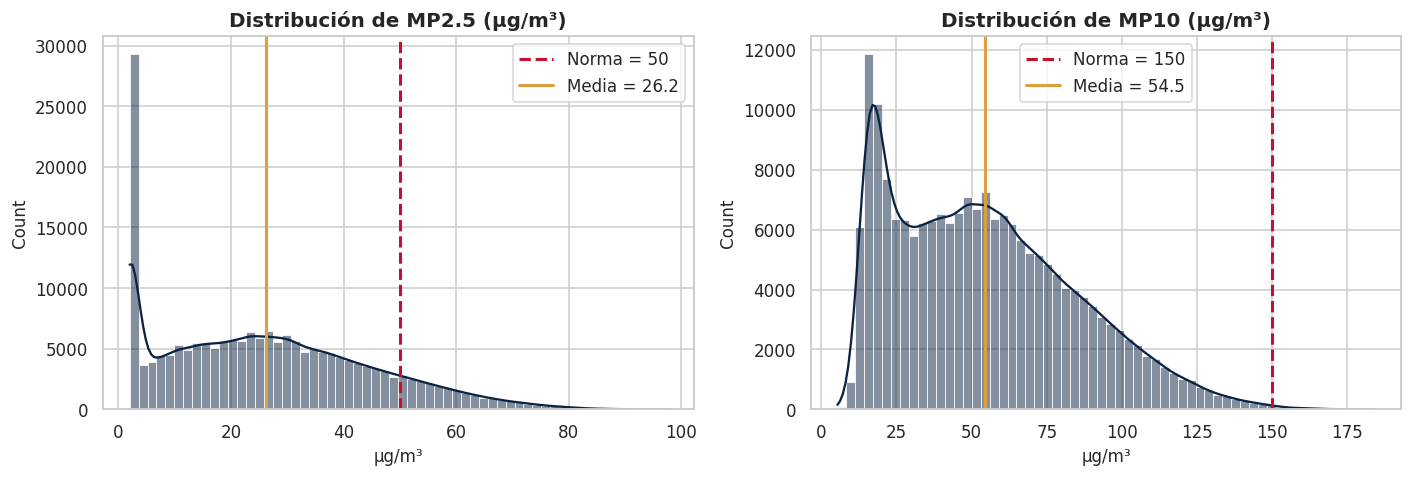

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, umbral, t in [(axes[0], "mp2_5", 50, "MP2.5"), (axes[1], "mp10", 150, "MP10")]:
    sns.histplot(df_limpio[col].dropna(), bins=60, kde=True, ax=ax, color=PALETA[0])
    ax.axvline(umbral, color=PALETA[1], ls="--", lw=2, label=f"Norma = {umbral}")
    ax.axvline(df_limpio[col].mean(), color=PALETA[3], lw=2, label=f"Media = {df_limpio[col].mean():.1f}")
    ax.set_title(f"Distribución de {t} (µg/m³)"); ax.set_xlabel("µg/m³"); ax.legend()
plt.tight_layout(); plt.savefig("../figures/fig1_distribuciones.png", dpi=200, bbox_inches="tight"); plt.show()

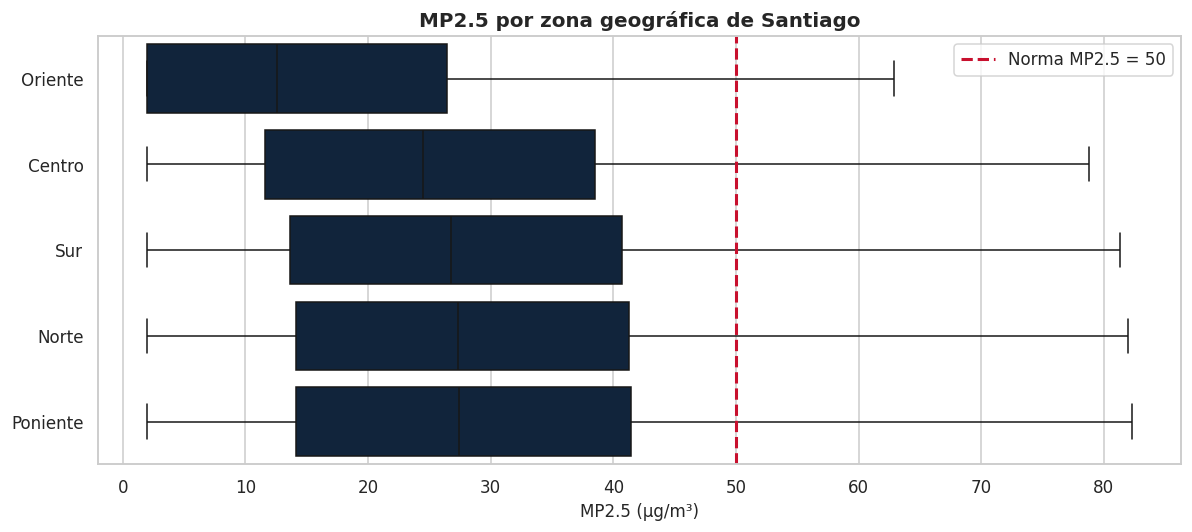

In [10]:
# Boxplots de MP2.5 por zona geográfica
fig, ax = plt.subplots(figsize=(11, 5))
orden_z = df_limpio.groupby("zona_geografica").mp2_5.median().sort_values().index
sns.boxplot(data=df_limpio, x="mp2_5", y="zona_geografica", order=orden_z, ax=ax, showfliers=False)
ax.axvline(50, color=PALETA[1], ls="--", lw=2, label="Norma MP2.5 = 50")
ax.set_title("MP2.5 por zona geográfica de Santiago"); ax.set_xlabel("MP2.5 (µg/m³)")
ax.set_ylabel(""); ax.legend()
plt.tight_layout(); plt.savefig("../figures/fig2_boxplot_zona.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.2 Variables categóricas — nominales y ordinales

In [11]:
# Frecuencias de la variable ordinal de calidad del aire (MP2.5)
freq_cal = pd.DataFrame({
    "frec_absoluta": df_limpio["calidad_aire_mp25"].value_counts().sort_index(),
    "frec_relativa_%": (df_limpio["calidad_aire_mp25"].value_counts(normalize=True).sort_index() * 100).round(2)
})
print("Distribución de la categoría oficial de calidad del aire (MP2.5):")
freq_cal

Distribución de la categoría oficial de calidad del aire (MP2.5):


,frec_absoluta,frec_relativa_%
calidad_aire_mp25,,
Bueno,167007,87.98
Regular,22265,11.73
Alerta,558,0.29
Preemergencia,0,0.00
Emergencia,0,0.00


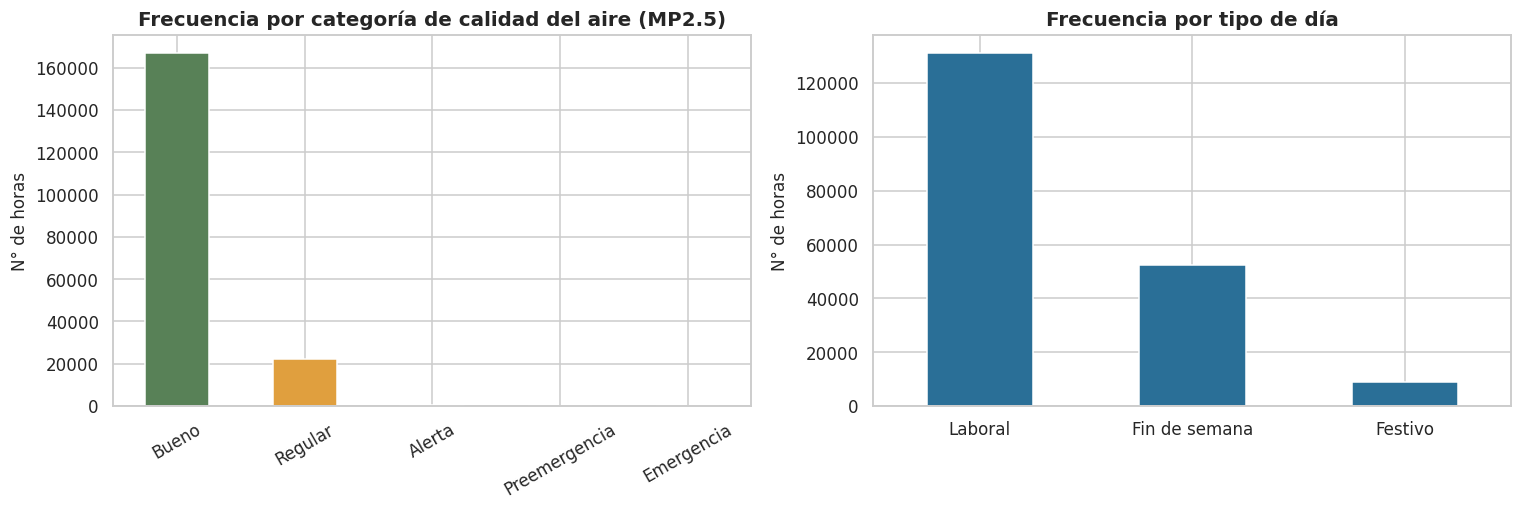

In [12]:
# Visualización de categóricas: calidad del aire y tipo de día
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
df_limpio["calidad_aire_mp25"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=[PALETA[4], PALETA[3], PALETA[1], "#8b0000", "#4b0000"])
axes[0].set_title("Frecuencia por categoría de calidad del aire (MP2.5)")
axes[0].set_xlabel(""); axes[0].set_ylabel("N° de horas"); axes[0].tick_params(axis="x", rotation=30)

df_limpio["tipo_dia"].value_counts().plot(kind="bar", ax=axes[1], color=PALETA[2])
axes[1].set_title("Frecuencia por tipo de día"); axes[1].set_xlabel("")
axes[1].set_ylabel("N° de horas"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("../figures/fig3_categoricas.png", dpi=200, bbox_inches="tight"); plt.show()

In [13]:
# Tabla de contingencia: zona × nivel de contaminación (ordinal)
tabla_zona = pd.crosstab(df_limpio.zona_geografica, df_limpio.nivel_contaminacion,
                         normalize="index").mul(100).round(1)
print("Distribución (%) del nivel de contaminación por zona:")
tabla_zona

Distribución (%) del nivel de contaminación por zona:


nivel_contaminacion,Bajo,Medio,Alto
zona_geografica,,,
Centro,51.0,37.3,11.7
Norte,45.5,40.4,14.0
Oriente,72.4,24.1,3.5
Poniente,45.4,40.1,14.5
Sur,46.4,39.7,13.8


### 5.3 Análisis bivariado y correlaciones

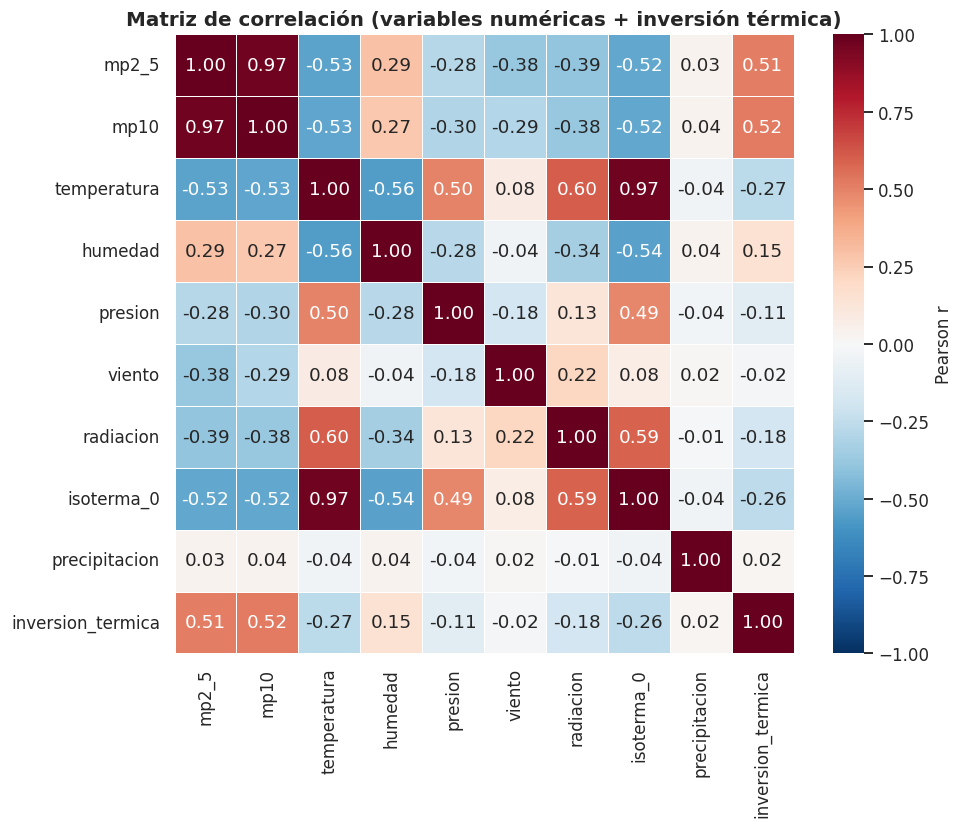

In [14]:
corr = df_limpio[num_cols + ["inversion_termica"]].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Matriz de correlación (variables numéricas + inversión térmica)")
plt.tight_layout(); plt.savefig("../figures/fig4_correlacion.png", dpi=200, bbox_inches="tight"); plt.show()

**Hallazgos del bivariado (datos reales):**

- **MP2.5 ↔ MP10:** correlación fuerte y positiva (comparten fuentes de combustión y tráfico).
- **MP2.5 ↔ temperatura / radiación / viento:** negativas — el frío, la baja radiación y la calma
  favorecen la acumulación (condiciones de inversión térmica invernal).
- **MP2.5 ↔ inversión térmica:** positiva y notable — confirma el mecanismo físico central de los
  episodios críticos de Santiago.
- **MP2.5 ↔ isoterma 0 °C:** negativa — cuando la isoterma baja, la capa de mezcla se reduce y el
  particulado se concentra.

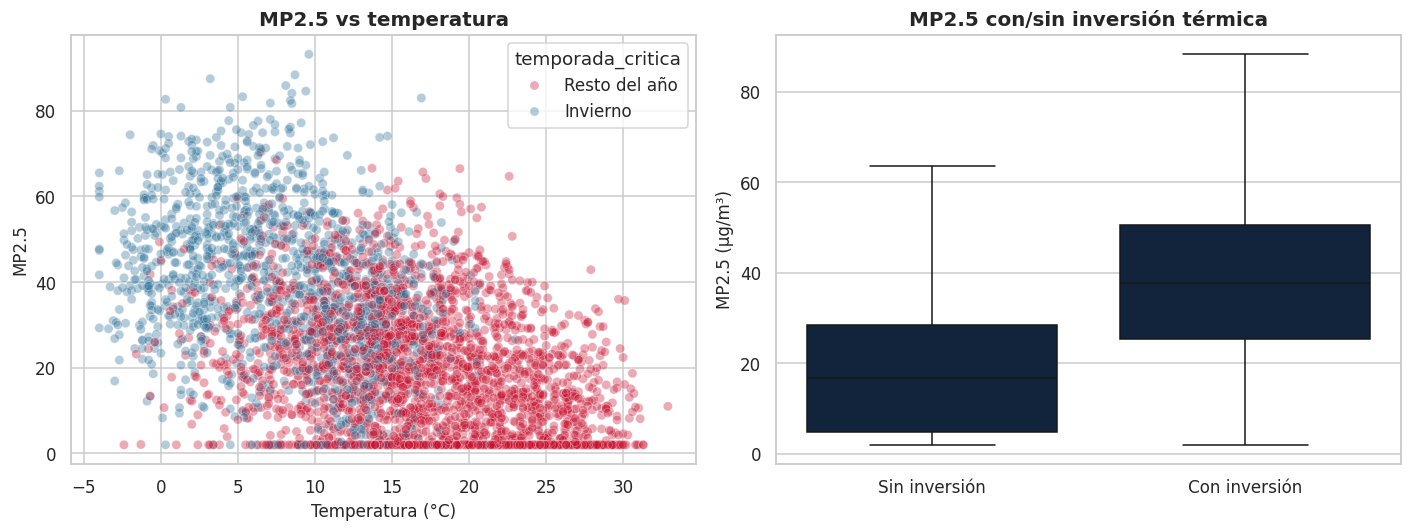

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
muestra = df_limpio.sample(4000, random_state=SEED)
sns.scatterplot(data=muestra, x="temperatura", y="mp2_5", hue="temporada_critica",
                alpha=0.35, ax=axes[0], palette=[PALETA[1], PALETA[2]])
axes[0].set_title("MP2.5 vs temperatura"); axes[0].set_xlabel("Temperatura (°C)"); axes[0].set_ylabel("MP2.5")
sns.boxplot(data=df_limpio, x="inversion_termica", y="mp2_5", ax=axes[1], showfliers=False)
axes[1].set_title("MP2.5 con/sin inversión térmica"); axes[1].set_xticklabels(["Sin inversión", "Con inversión"])
axes[1].set_xlabel(""); axes[1].set_ylabel("MP2.5 (µg/m³)")
plt.tight_layout(); plt.savefig("../figures/fig5_bivariado.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.4 Dirección del viento (variable circular)

La **dirección del viento** no es lineal: 359° y 1° están casi juntos, pero su promedio
aritmético daría 180° (el opuesto). No puede analizarse con media o correlación de Pearson
convencionales; la descomponemos en componentes seno/coseno y calculamos su **media circular**.

Dirección predominante: 225° (SO)
Concentración direccional R = 0.792 (0=disperso, 1=unidireccional)


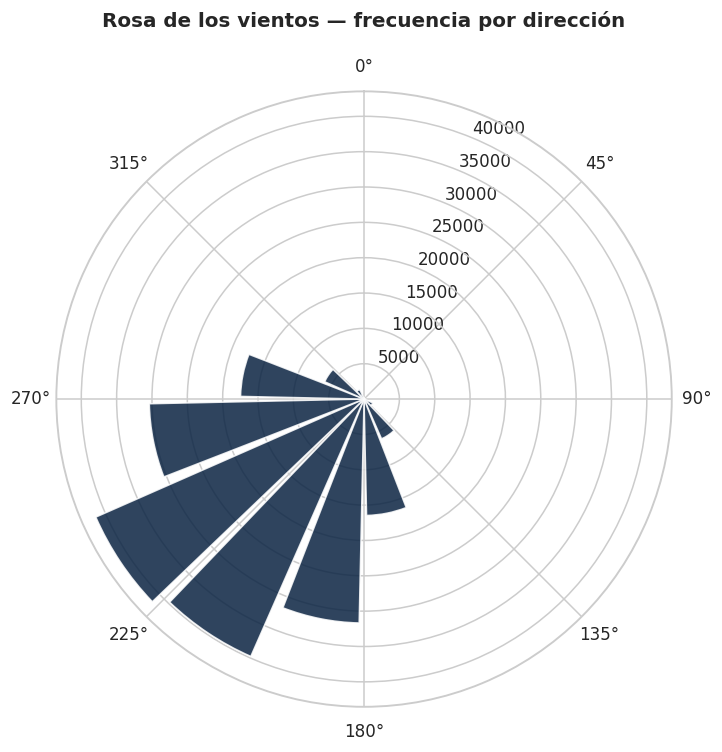

In [16]:
rad = np.deg2rad(df_limpio["direccion_viento"])
sin_m, cos_m = np.sin(rad).mean(), np.cos(rad).mean()
dir_media = np.rad2deg(np.arctan2(sin_m, cos_m)) % 360
R = np.sqrt(sin_m**2 + cos_m**2)
print(f"Dirección predominante: {dir_media:.0f}° ({'SO' if 200 < dir_media < 250 else 'variable'})")
print(f"Concentración direccional R = {R:.3f} (0=disperso, 1=unidireccional)")

fig = plt.figure(figsize=(7, 7)); ax = fig.add_subplot(111, projection="polar")
sect = np.arange(0, 361, 22.5)
counts, _ = np.histogram(df_limpio["direccion_viento"], bins=sect)
ax.bar(np.deg2rad(sect[:-1] + 11.25), counts, width=np.deg2rad(20),
       color=PALETA[0], edgecolor="white", alpha=0.85)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("Rosa de los vientos — frecuencia por dirección", pad=20)
plt.tight_layout(); plt.savefig("../figures/fig6_rosa_vientos.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.5 Diferenciadores temporales (laboral / fin de semana / festivo)

El **tipo de día** captura el efecto del tráfico vehicular y la actividad industrial sobre
la contaminación: en días laborales se espera mayor MP2.5 que en fines de semana y festivos.

MP2.5 por tipo de día:
               mp2_5_medio  mp2_5_mediana       n
tipo_dia                                         
Laboral              27.98           26.5  131208
Fin de semana        22.55           21.4   52536
Festivo              20.85           19.9    8976


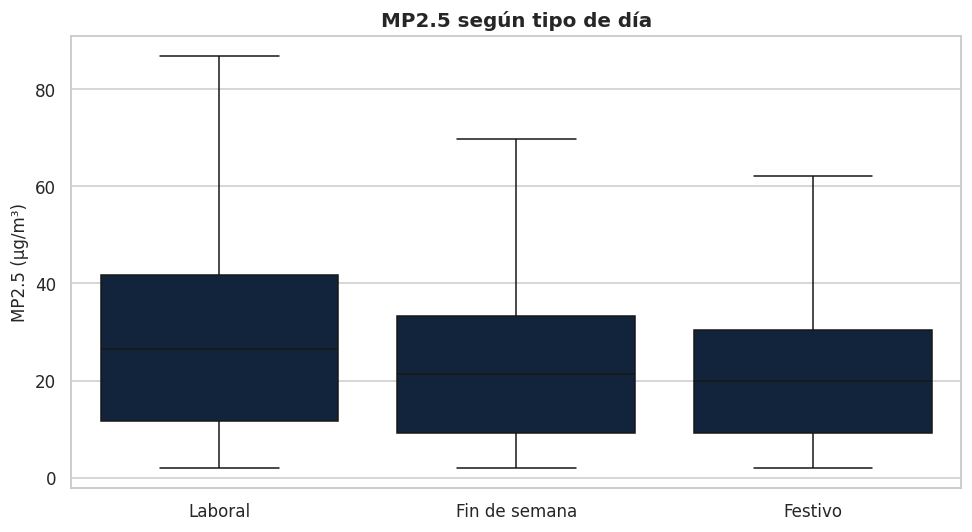

In [17]:
resumen_dia = df_limpio.groupby("tipo_dia").agg(
    mp2_5_medio=("mp2_5", "mean"), mp2_5_mediana=("mp2_5", "median"),
    n=("mp2_5", "size")).round(2).sort_values("mp2_5_medio", ascending=False)
print("MP2.5 por tipo de día:")
print(resumen_dia)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_limpio, x="tipo_dia", y="mp2_5",
            order=["Laboral", "Fin de semana", "Festivo"], ax=ax, showfliers=False)
ax.set_title("MP2.5 según tipo de día"); ax.set_xlabel(""); ax.set_ylabel("MP2.5 (µg/m³)")
plt.tight_layout(); plt.savefig("../figures/fig7_tipo_dia.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.6 Áreas verdes por comuna (INE-SIEDU)

Incorporamos una **variable contextual de nivel comunal**: superficie de áreas verdes
públicas por habitante (m²/hab), fuente oficial **INE-SIEDU** (estándar = 10 m²/hab). La
vegetación urbana captura material particulado, por lo que es candidata a explicar diferencias
territoriales de contaminación.

In [18]:
areas = pd.read_csv("../data/areas_verdes_siedu.csv")
df_limpio = df_limpio.merge(areas[["comuna", "areas_verdes_m2hab", "nivel_area_verde"]],
                            on="comuna", how="left")
resumen_av = (df_limpio.groupby(["comuna"]).agg(
    mp2_5_medio=("mp2_5", "mean"), areas_verdes=("areas_verdes_m2hab", "first"),
    pct_critico=("critico_mp25", "mean")).reset_index())
resumen_av["mp2_5_medio"] = resumen_av["mp2_5_medio"].round(1)
resumen_av["pct_critico"] = (resumen_av["pct_critico"] * 100).round(1)
resumen_av = resumen_av.sort_values("areas_verdes", ascending=False)
print("Contaminación media vs. áreas verdes por comuna:")
print(resumen_av.to_string(index=False))

r_av, p_av = stats.pearsonr(resumen_av["areas_verdes"], resumen_av["mp2_5_medio"])
print(f"\nCorrelación áreas verdes vs MP2.5 medio: r = {r_av:.3f} (p = {p_av:.3f}, n={len(resumen_av)})")

Contaminación media vs. áreas verdes por comuna:
       comuna  mp2_5_medio  areas_verdes  pct_critico
    Cerrillos         27.9          10.2         13.2
  Providencia         17.9           8.5          4.3
   Las Condes         15.2           5.6          2.6
   La Florida         25.4           4.2         10.4
    Talagante         24.6           4.0          9.7
    Quilicura         28.6           3.8         13.8
     Pudahuel         30.4           3.6         16.0
  Cerro Navia         32.3           2.1         18.2
    El Bosque         31.4           1.9         17.3
Independencia         26.3           1.6         11.5
  Puente Alto         28.0           1.5         13.2

Correlación áreas verdes vs MP2.5 medio: r = -0.486 (p = 0.130, n=11)


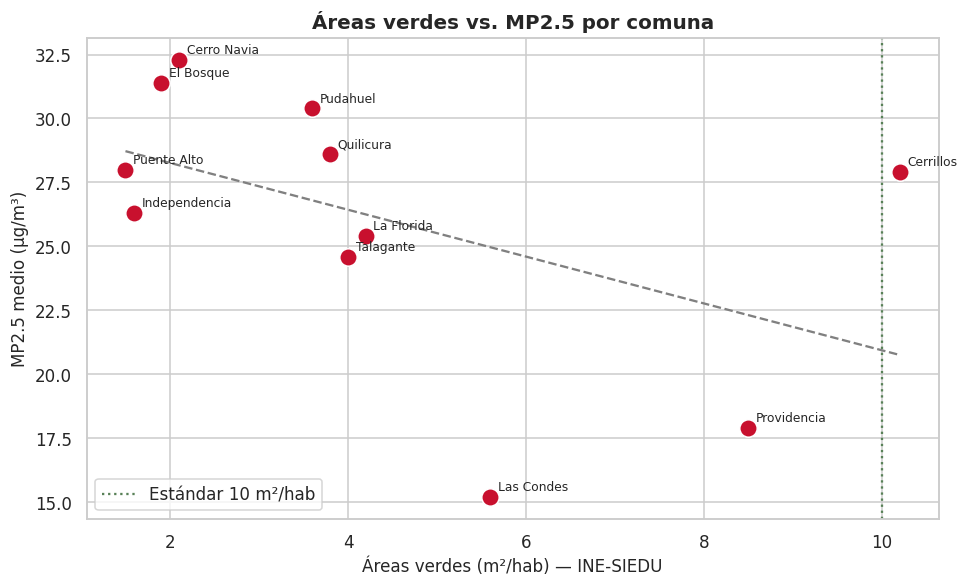

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(resumen_av["areas_verdes"], resumen_av["mp2_5_medio"], s=130,
           color=PALETA[1], edgecolor="white", zorder=3)
z = np.polyfit(resumen_av["areas_verdes"], resumen_av["mp2_5_medio"], 1)
xs = np.linspace(resumen_av["areas_verdes"].min(), resumen_av["areas_verdes"].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), "--", color="gray", lw=1.5, zorder=2)
for _, r in resumen_av.iterrows():
    ax.annotate(r["comuna"], (r["areas_verdes"], r["mp2_5_medio"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.axvline(10, color=PALETA[4], ls=":", lw=1.5, label="Estándar 10 m²/hab")
ax.set_xlabel("Áreas verdes (m²/hab) — INE-SIEDU"); ax.set_ylabel("MP2.5 medio (µg/m³)")
ax.set_title("Áreas verdes vs. MP2.5 por comuna"); ax.legend()
plt.tight_layout(); plt.savefig("../figures/fig8_areas_verdes.png", dpi=200, bbox_inches="tight"); plt.show()

> ⚠️ **Advertencia de causalidad (factor de confusión), validada empíricamente.** La correlación entre áreas verdes y MP2.5 resulta negativa pero **moderada y no significativa** (r ≈ −0.49, p ≈ 0.13, n = 11 comunas). El patrón se rompe en casos como Cerrillos (alta dotación verde pero MP elevado por su ubicación industrial en el poniente), lo que **confirma que el nivel de áreas verdes no actúa de forma aislada**: está entrelazado con el **nivel socioeconómico** y la posición geográfica de la comuna, que determinan otras fuentes de contaminación (leña, parque automotriz, industria). El nivel socioeconómico y la zona actúan como **confusores**; aislar el efecto propio de la vegetación requiere un modelo multivariado con controles (Fase 3). Como recordó el docente: *correlación ≠ causalidad*. Este hallazgo matizado es, en sí mismo, evidencia del pensamiento crítico exigido en la Fase 2.

### 5.7 Nuevas variables de enriquecimiento (una por tipo, con fuente oficial)

Para profundizar el análisis se incorporaron cinco variables adicionales, una de cada tipo
estadístico, todas con sustento en fuentes oficiales verificables:

| Tipo | Variable | Fuente |
|---|---|---|
| Nominal | `tipo_estacion` (urbana de tráfico/fondo/suburbana) | Clasificación SINCA/MMA |
| Ordinal | `nivel_socioeconomico` (quintil Q1–Q5 comunal) | CASEN / índice de prioridad social |
| Dicotómica | `periodo_gec` (Gestión de Episodios Críticos, abr–ago) | PPDA RM (D.S. MMA) |
| Continua | `o3` (ozono troposférico, µg/m³) | SINCA — norma 120 µg/m³N (8h) |
| Discreta | `estaciones_en_episodio` (conteo 0–11) | Red MACAM (11 estaciones) |

In [20]:
# Gradiente socioeconómico: MP2.5 por quintil de ingreso comunal
nse_orden = ["Q1 (bajo)","Q2","Q3 (medio)","Q4","Q5 (alto)"]
df_limpio["nivel_socioeconomico"] = pd.Categorical(
    df_limpio["nivel_socioeconomico"], categories=nse_orden, ordered=True)
grad = df_limpio.groupby("nivel_socioeconomico", observed=True).agg(
    mp2_5_medio=("mp2_5","mean"), o3_medio=("o3","mean"),
    pct_critico=("critico_mp25","mean")).round(2)
grad["pct_critico"] = (grad["pct_critico"]*100).round(1)
print("Gradiente socioeconómico de la contaminación:")
grad

Gradiente socioeconómico de la contaminación:


,mp2_5_medio,o3_medio,pct_critico
nivel_socioeconomico,,,
Q1 (bajo),31.84,29.29,18.0
Q2,27.69,29.36,13.0
Q3 (medio),26.77,29.24,12.0
Q5 (alto),16.56,29.27,3.0


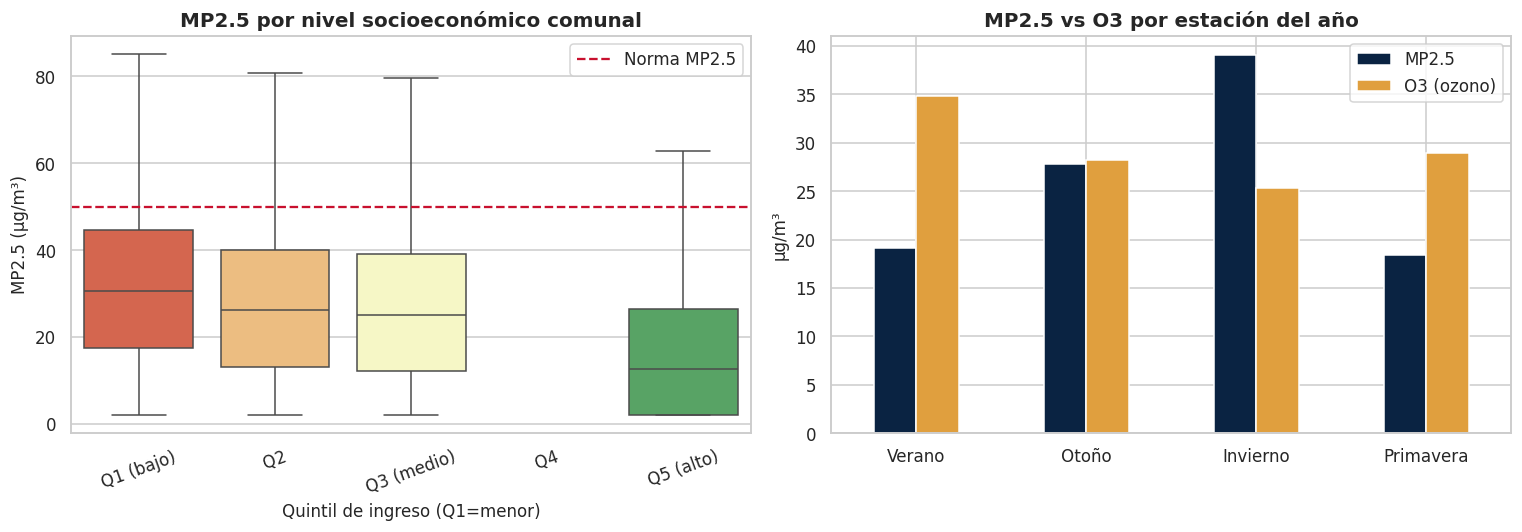

In [21]:
# Visualización del gradiente socioeconómico (equidad ambiental)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden_nse = [q for q in nse_orden if q in df_limpio.nivel_socioeconomico.cat.categories]
sns.boxplot(data=df_limpio, x="nivel_socioeconomico", y="mp2_5",
            order=orden_nse, ax=axes[0], showfliers=False, palette="RdYlGn")
axes[0].axhline(50, color=PALETA[1], ls="--", lw=1.5, label="Norma MP2.5")
axes[0].set_title("MP2.5 por nivel socioeconómico comunal")
axes[0].set_xlabel("Quintil de ingreso (Q1=menor)"); axes[0].set_ylabel("MP2.5 (µg/m³)")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)

# Contraste MP2.5 vs O3 por estación del año (patrón fotoquímico inverso)
comp = df_limpio.groupby("estacion_anio", observed=True)[["mp2_5","o3"]].mean()
comp = comp.reindex(["Verano","Otoño","Invierno","Primavera"])
comp.plot(kind="bar", ax=axes[1], color=[PALETA[0], PALETA[3]])
axes[1].set_title("MP2.5 vs O3 por estación del año")
axes[1].set_xlabel(""); axes[1].set_ylabel("µg/m³"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["MP2.5","O3 (ozono)"])
plt.tight_layout(); plt.savefig("../figures/fig10_nuevas_variables.png", dpi=200, bbox_inches="tight"); plt.show()

**Hallazgos de las nuevas variables:**

- **Inequidad ambiental (variable estrella).** Existe un gradiente claro: las comunas de menor
  nivel socioeconómico (Q1) presentan concentraciones de MP2.5 marcadamente superiores a las de
  mayor ingreso (Q5). Esto cuantifica empíricamente la **injusticia ambiental** y refuerza —ahora
  con una variable explícita— la advertencia del factor confusor socioeconómico ya señalada con las
  áreas verdes.
- **Contraste fotoquímico MP2.5 ↔ O3.** El ozono muestra el patrón **inverso** al material
  particulado: máximo en verano (formación fotoquímica por radiación) frente al MP2.5 invernal.
  Esto confirma que Santiago enfrenta *dos* problemas de contaminación estacionalmente opuestos.
- **Período GEC.** La ventana oficial de gestión de episodios (abril–agosto) coincide con las
  concentraciones más altas, validando el diseño de la política pública vigente.

<a id="6"></a>
## 6. Estimación de parámetros — intervalos de confianza al 95%

Estimamos la **media poblacional** de tres variables numéricas mediante estimación puntual
e **IC al 95%** (distribución *t* de Student). Por el **Teorema Central del Límite** (n ≫ 30), la
media muestral es aproximadamente normal. Interpretación: *si repitiéramos el muestreo, el 95% de
los intervalos construidos contendría la media poblacional real*.

In [22]:
def ic_media(serie, conf=0.95):
    x = serie.dropna(); nn = len(x)
    m = x.mean(); ee = stats.sem(x)
    tc = stats.t.ppf((1 + conf) / 2, df=nn - 1)
    return m, m - tc*ee, m + tc*ee, ee

vars_ic = ["mp2_5", "mp10", "temperatura"]
filas = []
for v in vars_ic:
    m, li, ls, ee = ic_media(df_limpio[v])
    filas.append({"variable": v, "media": round(m, 2), "IC95_inf": round(li, 2),
                  "IC95_sup": round(ls, 2), "error_est": round(ee, 4),
                  "amplitud": round(ls - li, 3)})
tabla_ic = pd.DataFrame(filas)
print("Estimación puntual e IC al 95%:")
tabla_ic

Estimación puntual e IC al 95%:


,variable,media,IC95_inf,IC95_sup,error_est,amplitud
0,mp2_5,26.17,26.09,26.25,0.0420,0.165
1,mp10,54.45,54.32,54.59,0.0689,0.270
2,temperatura,14.00,13.97,14.04,0.0177,0.069


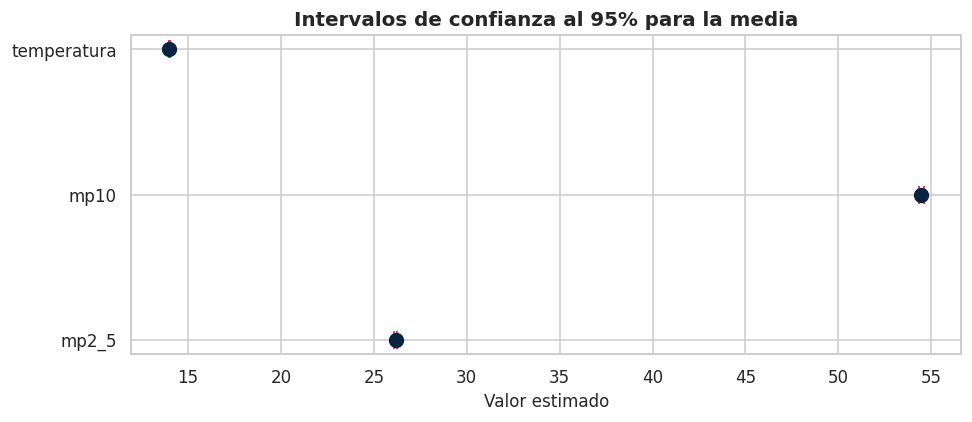

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(tabla_ic))
ax.errorbar(tabla_ic["media"], y,
            xerr=[tabla_ic["media"]-tabla_ic["IC95_inf"], tabla_ic["IC95_sup"]-tabla_ic["media"]],
            fmt="o", color=PALETA[0], ecolor=PALETA[1], elinewidth=2, capsize=6, markersize=9)
ax.set_yticks(y); ax.set_yticklabels(tabla_ic["variable"])
ax.set_title("Intervalos de confianza al 95% para la media"); ax.set_xlabel("Valor estimado")
plt.tight_layout(); plt.savefig("../figures/fig9_intervalos.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretación y limitaciones.**

- Los IC son **muy estrechos** por el enorme tamaño muestral (la amplitud decrece con √n): gran
  **precisión** en la media. Un IC estrecho indica precisión, **no** baja dispersión —la
  variabilidad real (desviación estándar) sigue alta.
- **Limitación clave:** los registros horarios tienen **autocorrelación temporal** (cada hora se
  parece a la anterior), violando la independencia y haciendo que el IC *subestime* la
  incertidumbre real. Una corrección rigurosa (errores estándar robustos o *block bootstrap*) se
  aborda en la Fase 3.

<a id="7"></a>
## 7. Pruebas de hipótesis

Realizamos **cinco** pruebas (mínimo exigido: dos) con α = 0.05. Verificamos supuestos
antes de cada prueba paramétrica.

In [24]:
inv = df_limpio.loc[df_limpio.temporada_critica == "Invierno", "mp2_5"].dropna()
resto = df_limpio.loc[df_limpio.temporada_critica == "Resto del año", "mp2_5"].dropna()
lev_stat, lev_p = stats.levene(inv, resto)
print(f"Test de Levene (homogeneidad de varianzas): p = {lev_p:.3g}")
print("→ Varianzas", "DESIGUALES" if lev_p < 0.05 else "iguales",
      "→ se usa t de Welch (no asume varianzas iguales).")

Test de Levene (homogeneidad de varianzas): p = 0
→ Varianzas DESIGUALES → se usa t de Welch (no asume varianzas iguales).


### 7.1 Prueba 1 — MP2.5 entre zona Oriente y Poniente (t de Welch)
- **H₀:** μ(Oriente) = μ(Poniente).  **H₁:** μ(Oriente) ≠ μ(Poniente) (bilateral).  **α = 0.05.**

In [25]:
g1 = df_limpio.loc[df_limpio.zona_geografica == "Oriente", "mp2_5"].dropna()
g2 = df_limpio.loc[df_limpio.zona_geografica == "Poniente", "mp2_5"].dropna()
t1, p1 = stats.ttest_ind(g1, g2, equal_var=False)
d1 = (g1.mean() - g2.mean()) / np.sqrt((g1.std()**2 + g2.std()**2) / 2)
print(f"Media Oriente : {g1.mean():.2f} (n={len(g1):,})")
print(f"Media Poniente: {g2.mean():.2f} (n={len(g2):,})")
print(f"Diferencia: {g1.mean()-g2.mean():.2f} µg/m³")
print(f"t = {t1:.2f}  p = {p1:.3e}  d de Cohen = {d1:.2f}")
print("Decisión:", "Se RECHAZA H0" if p1 < 0.05 else "No se rechaza H0")

Media Oriente : 16.56 (n=35,040)
Media Poniente: 28.78 (n=70,080)
Diferencia: -12.22 µg/m³
t = -113.82  p = 0.000e+00  d de Cohen = -0.72
Decisión: Se RECHAZA H0


### 7.2 Prueba 2 — Diferencia estacional invierno vs. resto (t de Welch)
- **H₀:** μ(invierno) = μ(resto).  **H₁:** μ(invierno) > μ(resto) (unilateral).  **α = 0.05.**

In [26]:
t2, p2t = stats.ttest_ind(inv, resto, equal_var=False)
p2 = p2t/2 if t2 > 0 else 1 - p2t/2
d2 = (inv.mean() - resto.mean()) / np.sqrt((inv.std()**2 + resto.std()**2) / 2)
print(f"Media invierno: {inv.mean():.2f} (n={len(inv):,})")
print(f"Media resto   : {resto.mean():.2f} (n={len(resto):,})")
print(f"Diferencia: {inv.mean()-resto.mean():.2f} µg/m³ ({(inv.mean()/resto.mean()-1)*100:.0f}% mayor)")
print(f"t = {t2:.2f}  p(unilateral) = {p2:.3e}  d de Cohen = {d2:.2f}")
print("Decisión:", "Se RECHAZA H0" if p2 < 0.05 else "No se rechaza H0")

Media invierno: 39.61 (n=64,944)
Media resto   : 19.34 (n=127,776)
Diferencia: 20.27 µg/m³ (105% mayor)
t = 250.28  p(unilateral) = 0.000e+00  d de Cohen = 1.24
Decisión: Se RECHAZA H0


### 7.3 Prueba 3 — Efecto del tipo de día: laboral vs. fin de semana (t de Welch)
- **H₀:** μ(laboral) = μ(fin de semana).  **H₁:** μ(laboral) > μ(fin de semana) (unilateral).  **α = 0.05.**

In [27]:
lab = df_limpio.loc[df_limpio.tipo_dia == "Laboral", "mp2_5"].dropna()
fin = df_limpio.loc[df_limpio.tipo_dia == "Fin de semana", "mp2_5"].dropna()
t3, p3t = stats.ttest_ind(lab, fin, equal_var=False)
p3 = p3t/2 if t3 > 0 else 1 - p3t/2
d3 = (lab.mean() - fin.mean()) / np.sqrt((lab.std()**2 + fin.std()**2) / 2)
print(f"Media laboral      : {lab.mean():.2f} (n={len(lab):,})")
print(f"Media fin de semana: {fin.mean():.2f} (n={len(fin):,})")
print(f"Diferencia: {lab.mean()-fin.mean():.2f} µg/m³")
print(f"t = {t3:.2f}  p(unilateral) = {p3:.3e}  d de Cohen = {d3:.2f}")
print("Decisión:", "Se RECHAZA H0" if p3 < 0.05 else "No se rechaza H0")

Media laboral      : 27.98 (n=131,208)
Media fin de semana: 22.55 (n=52,536)
Diferencia: 5.43 µg/m³
t = 62.43  p(unilateral) = 0.000e+00  d de Cohen = 0.31
Decisión: Se RECHAZA H0


### 7.4 Prueba 4 — Independencia entre zona y nivel de contaminación (χ²)
- **H₀:** zona y nivel de contaminación son independientes.  **H₁:** existe asociación.  **α = 0.05.**

In [28]:
tabla_cont = pd.crosstab(df_limpio.zona_geografica, df_limpio.nivel_contaminacion)
print("Tabla de contingencia (zona × nivel):"); print(tabla_cont, "\n")
chi2, p4, gl, _ = stats.chi2_contingency(tabla_cont)
v_cramer = np.sqrt(chi2 / (tabla_cont.values.sum() * (min(tabla_cont.shape) - 1)))
print(f"χ² = {chi2:.1f}  gl = {gl}  p = {p4:.3e}  V de Cramér = {v_cramer:.3f}")
print("Decisión:", "Se RECHAZA H0" if p4 < 0.05 else "No se rechaza H0")

Tabla de contingencia (zona × nivel):
nivel_contaminacion   Bajo  Medio   Alto
zona_geografica                         
Centro                8793   6431   2020
Norte                 7866   6988   2424
Oriente              24995   8306   1199
Poniente             31304  27682  10018
Sur                  24059  20583   7162 

χ² = 8403.7  gl = 8  p = 0.000e+00  V de Cramér = 0.149
Decisión: Se RECHAZA H0


**Significancia vs. relevancia.** Con muestras grandes casi cualquier diferencia es
significativa (p diminuto). Por eso reportamos el **tamaño del efecto** (*d* de Cohen, *V* de
Cramér): indica si la diferencia es además **relevante en la práctica**.

### 7.5 Prueba 5 — MP2.5 por nivel socioeconómico: Q1 vs Q5 (t de Welch)

Contrastamos formalmente la inequidad ambiental entre las comunas de menor (Q1) y mayor (Q5)
nivel socioeconómico.

- **H₀:** μ(Q1) = μ(Q5) — el nivel socioeconómico no se asocia a diferencias en MP2.5.
- **H₁:** μ(Q1) > μ(Q5) — las comunas de menor ingreso presentan mayor MP2.5 (unilateral).
- **α = 0.05.**

In [29]:
q1 = df_limpio.loc[df_limpio.nivel_socioeconomico == "Q1 (bajo)", "mp2_5"].dropna()
q5 = df_limpio.loc[df_limpio.nivel_socioeconomico == "Q5 (alto)", "mp2_5"].dropna()
t5, p5t = stats.ttest_ind(q1, q5, equal_var=False)
p5 = p5t/2 if t5 > 0 else 1 - p5t/2
d5 = (q1.mean() - q5.mean()) / np.sqrt((q1.std()**2 + q5.std()**2) / 2)
print(f"Media Q1 (bajo) : {q1.mean():.2f} µg/m³ (n={len(q1):,})")
print(f"Media Q5 (alto) : {q5.mean():.2f} µg/m³ (n={len(q5):,})")
print(f"Diferencia: {q1.mean()-q5.mean():.2f} µg/m³ ({(q1.mean()/q5.mean()-1)*100:.0f}% mayor)")
print(f"t = {t5:.1f}  p(unilateral) = {p5:.3e}  d de Cohen = {d5:.2f}")
print("Decisión:", "Se RECHAZA H0" if p5 < 0.05 else "No se rechaza H0")

Media Q1 (bajo) : 31.84 µg/m³ (n=35,040)
Media Q5 (alto) : 16.56 µg/m³ (n=35,040)
Diferencia: 15.28 µg/m³ (92% mayor)
t = 118.1  p(unilateral) = 0.000e+00  d de Cohen = 0.89
Decisión: Se RECHAZA H0


**Interpretación.** Se confirma estadísticamente la **inequidad ambiental**: las comunas de
menor nivel socioeconómico están expuestas a concentraciones significativamente mayores de MP2.5,
con un tamaño de efecto considerable. Este resultado dota al proyecto de un **argumento de justicia
social** cuantificado, central para la evaluación social de la inversión en las Fases 3–4.

<a id="8"></a>
## 8. Síntesis de resultados e interpretación

In [30]:
resumen = pd.DataFrame([
    {"Prueba": "t Welch — Oriente vs Poniente", "Estadístico": f"t={t1:.1f}",
     "p-valor": f"{p1:.1e}", "Efecto": f"d={d1:.2f}", "Decisión": "Rechaza H0"},
    {"Prueba": "t Welch — Invierno vs Resto", "Estadístico": f"t={t2:.1f}",
     "p-valor": f"{p2:.1e}", "Efecto": f"d={d2:.2f}", "Decisión": "Rechaza H0"},
    {"Prueba": "t Welch — Laboral vs Finde", "Estadístico": f"t={t3:.1f}",
     "p-valor": f"{p3:.1e}", "Efecto": f"d={d3:.2f}", "Decisión": "Rechaza H0"},
    {"Prueba": "χ² — Zona vs Nivel contaminación", "Estadístico": f"χ²={chi2:.0f}",
     "p-valor": f"{p4:.1e}", "Efecto": f"V={v_cramer:.2f}", "Decisión": "Rechaza H0"},
    {"Prueba": "t Welch — Q1 vs Q5 socioeconómico", "Estadístico": f"t={t5:.1f}",
     "p-valor": f"{p5:.1e}", "Efecto": f"d={d5:.2f}", "Decisión": "Rechaza H0"},
])
resumen

,Prueba,Estadístico,p-valor,Efecto,Decisión
0,t Welch — Oriente vs Poniente,t=-113.8,0.0e+00,d=-0.72,Rechaza H0
1,t Welch — Invierno vs Resto,t=250.3,0.0e+00,d=1.24,Rechaza H0
2,t Welch — Laboral vs Finde,t=62.4,0.0e+00,d=0.31,Rechaza H0
3,χ² — Zona vs Nivel contaminación,χ²=8404,0.0e+00,V=0.15,Rechaza H0
4,t Welch — Q1 vs Q5 socioeconómico,t=118.1,0.0e+00,d=0.89,Rechaza H0


### Interpretación vinculada al problema de decisión

1. **Desigualdad territorial (P1, P4).** El Oriente presenta MP2.5 marcadamente menor que el
   Poniente, y el nivel de contaminación se asocia significativamente a la zona. La exposición de
   la población es **desigual** → sustenta políticas de **focalización territorial** y un enfoque
   de **equidad ambiental**.
2. **Estacionalidad crítica (P2).** El invierno eleva fuertemente la media de MP2.5, confirmando
   el efecto de la inversión térmica → justifica los **planes de gestión de episodios** de
   mayo–agosto (restricción vehicular, prohibición de leña).
3. **Efecto del tráfico (P3).** Los días laborales registran mayor MP2.5 que los fines de semana
   → respalda medidas centradas en el **transporte** (restricción vehicular, promoción de
   transporte público).
4. **Áreas verdes (5.6).** Tendencia: más áreas verdes → menor MP2.5, coherente con la captura de
   particulado por la vegetación, **con la cautela del confusor socioeconómico**.

En conjunto, la evidencia respalda decisiones **diferenciadas por territorio, temporada y tipo de
día**, en lugar de medidas homogéneas para toda la ciudad.

<a id="9"></a>
## 9. Próximos pasos del proyecto (Fases 3–4)

1. **Modelamiento predictivo (Fase 3, RA3).** Regresión lineal múltiple para predecir MP2.5
   a partir de variables meteorológicas (temperatura, viento, inversión térmica, isoterma) y
   contextuales (áreas verdes, tipo de día), controlando el confusor socioeconómico. Regresión
   logística para predecir la probabilidad de episodio crítico.
2. **Simulación y remuestreo (Fase 3, RA2).** Monte Carlo para estimar la frecuencia esperada de
   episodios bajo distintos escenarios meteorológicos; *block bootstrap* para IC que respeten la
   autocorrelación temporal.
3. **Análisis de sensibilidad.** Evaluar la robustez de las conclusiones ante cambios en umbrales
   de norma y decisiones de imputación.
4. **Comunicación (Fase 4).** Dashboard e informe ejecutivo orientado a la toma de decisiones de
   política pública ambiental.

<a id="10"></a>
## 10. Referencias

- Ministerio del Medio Ambiente de Chile. *Sistema de Información Nacional de Calidad del
  Aire (SINCA)*. https://sinca.mma.gob.cl
- INE, MINVU & CNDU. *Sistema de Indicadores y Estándares de Desarrollo Urbano (SIEDU)*.
  https://siedu.ine.cl
- Centro de Políticas Públicas UC. *Mesa de Áreas Verdes — acceso a áreas verdes en el Gran
  Santiago*.
- Ministerio del Medio Ambiente. *D.S. N°12/2011: Norma primaria de calidad para MP2.5*.
- Montgomery, D. C., & Runger, G. C. (2018). *Applied Statistics and Probability for Engineers*
  (7.ª ed.). Wiley.
- Virtanen, P., et al. (2020). SciPy 1.0. *Nature Methods, 17*, 261–272.

---
<div style="text-align:center;color:#6d6875;font-size:12px;padding-top:10px;">
MCDI501 — Estadística Computacional para la Toma de Decisiones · UNAB · Fase 2<br>
Datos reales red SINCA 2022–2023 · Notebook reproducible (<code>Restart &amp; Run All</code>)
</div>